# 🧮 Optimización de Inventario - Modelo Newsvendor

## Problema
- Si compras **poco** → pierdes ventas (quiebre de stock)
- Si compras **mucho** → desperdicias (sobrestock)

## Pregunta clave
> **¿Cuánto debo comprar exactamente de cada insumo?**

## Enfoque técnico
1. **Forecast probabilístico** de demanda (distribución Normal)
2. **Modelo Newsvendor**: `Q* = μ_LT + z(SL) × σ_LT`
3. **Optimización bajo incertidumbre** con nivel de servicio configurable

## Resultado esperado
```
Compra óptima: 320 kg
Riesgo de faltante: 5%
Riesgo de desperdicio: 8%
```

---

### Pipeline de datos (dbt)
```
Silver (staging) → Intermediate (int_demanda_insumos)
                  → Features (feat_inventario_demanda)  
                  → Dataset (obt_inventory_optimization)
```

## 1. 📦 Setup y Conexión a Snowflake

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import snowflake.connector
from dotenv import load_dotenv
import mlflow
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

load_dotenv()
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [14]:
# Conexión a Snowflake
conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE', 'COMPUTE_WH'),
    database=os.getenv('SNOWFLAKE_DATABASE', 'HGC_DB'),
    schema='TRAINING_DATASETS'
)

# Extraer dataset desde Snowflake (generado por dbt run)
query = 'SELECT * FROM TRAINING_DATASETS.OBT_INVENTORY_OPTIMIZATION'
df = pd.read_sql(query, conn)
df.columns = [c.upper() for c in df.columns]

print(f'✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

✅ Dataset cargado: 24 filas × 30 columnas


,ID_INSUMO_NK,ID_ALMACEN_NK,NOMBRE_INSUMO,UNIDAD_MEDIDA,FEATURE_DEMANDA_PROMEDIO_DIARIA,FEATURE_DEMANDA_DESVIACION_STD,FEATURE_COEFICIENTE_VARIACION,FEATURE_DEMANDA_MEDIANA_DIARIA,FEATURE_DEMANDA_MINIMA_DIARIA,FEATURE_DEMANDA_MAXIMA_DIARIA,...,FEATURE_COSTO_UNITARIO,FEATURE_PRECIO_COMPRA_PROMEDIO,FEATURE_LEAD_TIME_DIAS,FEATURE_DEMANDA_ESPERADA_LT,FEATURE_DESVIACION_DEMANDA_LT,FEATURE_NUM_PRODUCTOS_DEPENDIENTES,META_DIAS_CON_DEMANDA,META_PRIMERA_FECHA,META_ULTIMA_FECHA,META_RANGO_DIAS
0,1,4,Pollo Crudo Entero,Kg,176.2528,114.7671,0.6512,139.510,54.30,659.30,...,15.5,15.5,3.050578,537.6728,200.4511,3,3939,2016-03-20,2026-12-31,3938
1,1,22,Pollo Crudo Entero,Kg,88.4140,16.3386,0.1848,87.520,47.70,143.55,...,15.5,15.5,3.050578,269.7137,28.5369,3,1184,2023-10-05,2026-12-31,1183
2,1,12,Pollo Crudo Entero,Kg,116.1054,38.4863,0.3315,106.070,45.53,252.36,...,15.5,15.5,3.050578,354.1886,67.2199,3,2638,2019-10-12,2026-12-31,2637
3,1,20,Pollo Crudo Entero,Kg,94.4482,18.8575,0.1997,92.420,50.76,160.64,...,15.5,15.5,3.050578,288.1216,32.9363,3,1781,2022-02-15,2026-12-31,1780
4,6,14,Cajas de Cartón Combo,Unidad,96.9113,20.5966,0.2125,95.005,50.42,177.34,...,1.2,1.2,2.916053,282.5985,35.1717,7,1880,2021-11-08,2026-12-31,1879


## 2. 🔍 Análisis Exploratorio de Datos (EDA)

In [15]:
# Resumen estadístico de las columnas clave
feature_cols = [c for c in df.columns if c.startswith('FEATURE_')]
print(f'Total de features: {len(feature_cols)}')
print(f'Insumos únicos: {df["ID_INSUMO_NK"].nunique()}')
print(f'Almacenes únicos: {df["ID_ALMACEN_NK"].nunique()}')
print()
df[feature_cols].describe().round(2)

Total de features: 22
Insumos únicos: 2
Almacenes únicos: 12



,FEATURE_DEMANDA_PROMEDIO_DIARIA,FEATURE_DEMANDA_DESVIACION_STD,FEATURE_COEFICIENTE_VARIACION,FEATURE_DEMANDA_MEDIANA_DIARIA,FEATURE_DEMANDA_MINIMA_DIARIA,FEATURE_DEMANDA_MAXIMA_DIARIA,FEATURE_DEMANDA_PROMEDIO_7D,FEATURE_DEMANDA_PROMEDIO_30D,FEATURE_TENDENCIA_DEMANDA_RATIO,FEATURE_DIAS_ACTIVOS_ULTIMO_MES,...,FEATURE_STOCK_MINIMO,FEATURE_STOCK_MAXIMO,FEATURE_INDICADOR_BAJO_STOCK,FEATURE_DIAS_COBERTURA_STOCK,FEATURE_COSTO_UNITARIO,FEATURE_PRECIO_COMPRA_PROMEDIO,FEATURE_LEAD_TIME_DIAS,FEATURE_DEMANDA_ESPERADA_LT,FEATURE_DESVIACION_DEMANDA_LT,FEATURE_NUM_PRODUCTOS_DEPENDIENTES
count,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,...,24.0,24.0,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00
mean,126.65,59.01,0.38,109.83,45.88,357.31,86.79,86.61,0.00,21946.25,...,50.0,1200.0,0.04,4.71,8.35,8.35,2.98,377.85,101.91,5.00
std,44.48,66.16,0.25,21.52,3.70,325.42,0.96,0.88,0.00,10633.29,...,0.0,0.0,0.20,2.79,7.30,7.30,0.07,133.02,114.27,2.04
min,86.69,15.88,0.18,86.24,39.64,133.30,85.17,85.03,-0.00,6111.00,...,50.0,1200.0,0.00,0.23,1.20,1.20,2.92,253.17,27.12,3.00
25%,93.85,18.55,0.20,92.13,43.31,157.01,86.05,86.00,0.00,14113.50,...,50.0,1200.0,0.00,2.68,1.20,1.20,2.92,279.63,31.76,3.00
50%,109.41,32.74,0.30,101.99,45.46,230.05,86.85,86.57,0.00,20224.50,...,50.0,1200.0,0.00,4.91,8.35,8.35,2.98,325.93,56.43,5.00
75%,144.98,64.81,0.45,125.54,47.74,389.09,87.40,87.19,0.00,31355.25,...,50.0,1200.0,0.00,6.59,15.50,15.50,3.05,436.74,112.23,7.00
max,238.24,251.17,1.05,151.21,54.30,1297.99,88.84,88.56,0.01,38121.00,...,50.0,1200.0,1.00,9.83,15.50,15.50,3.05,726.77,438.58,7.00


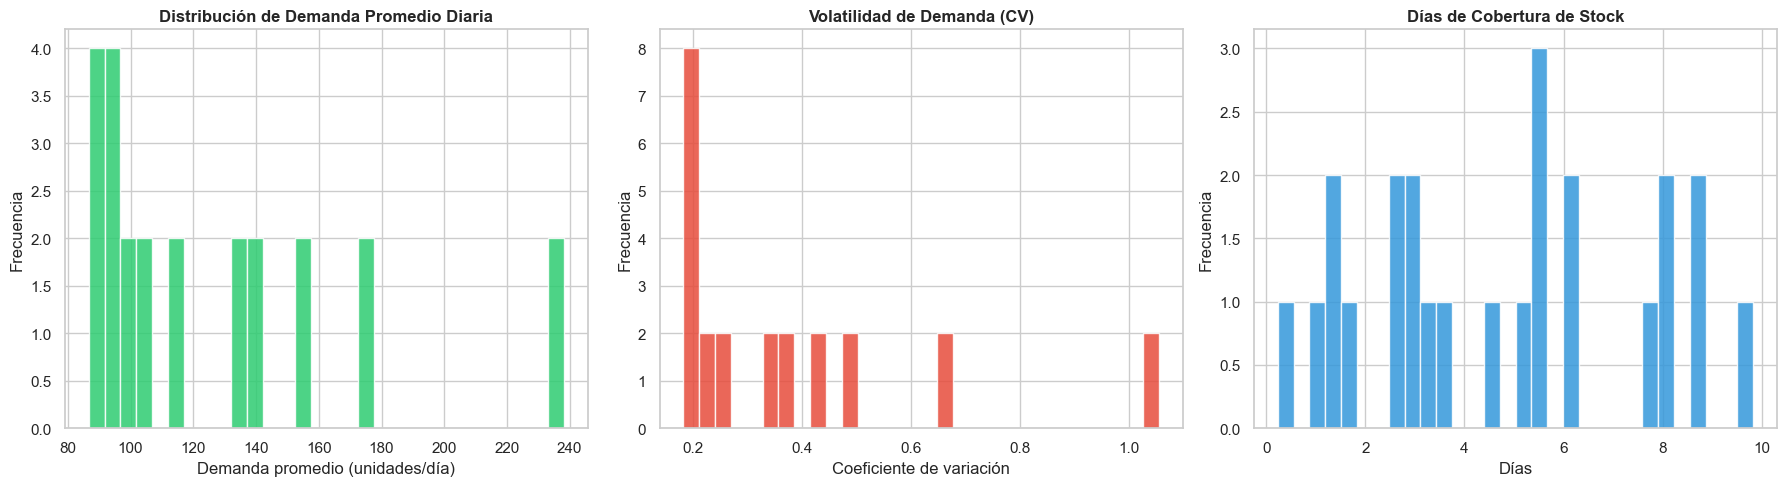

In [16]:
# Distribución de la demanda promedio diaria
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de demanda promedio
axes[0].hist(df['FEATURE_DEMANDA_PROMEDIO_DIARIA'], bins=30, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de Demanda Promedio Diaria', fontweight='bold')
axes[0].set_xlabel('Demanda promedio (unidades/día)')
axes[0].set_ylabel('Frecuencia')

# 2. Coeficiente de variación (volatilidad)
axes[1].hist(df['FEATURE_COEFICIENTE_VARIACION'], bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1].set_title('Volatilidad de Demanda (CV)', fontweight='bold')
axes[1].set_xlabel('Coeficiente de variación')
axes[1].set_ylabel('Frecuencia')

# 3. Días de cobertura de stock
cobertura = df['FEATURE_DIAS_COBERTURA_STOCK'].clip(upper=100)
axes[2].hist(cobertura, bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[2].set_title('Días de Cobertura de Stock', fontweight='bold')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

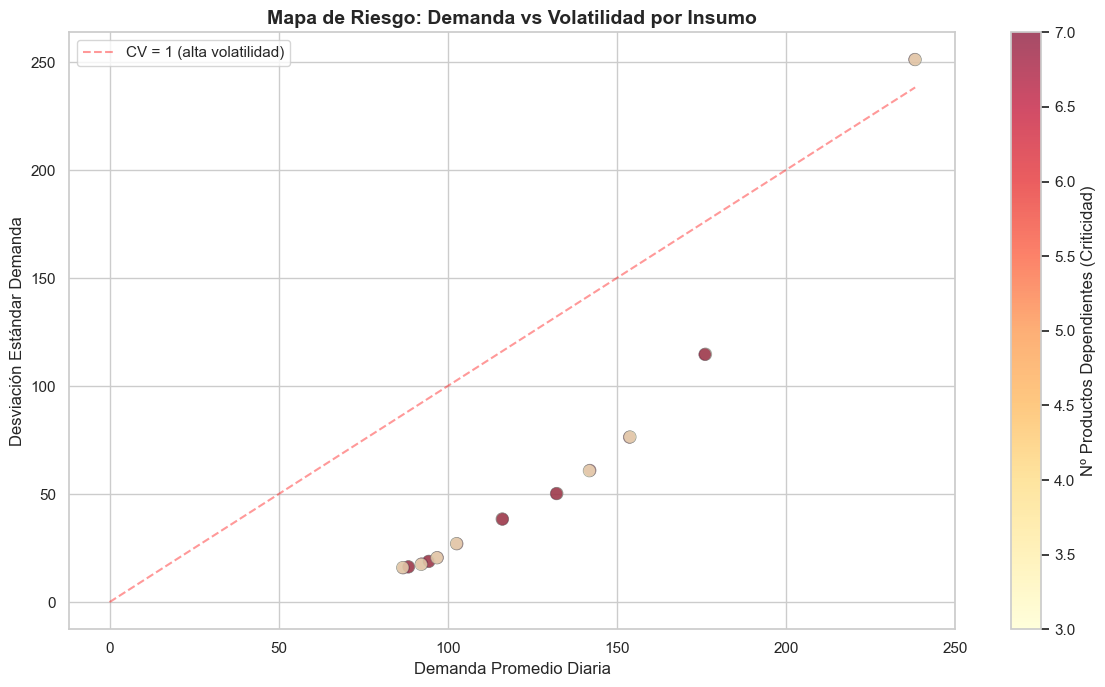

In [17]:
# Scatter: Demanda vs Desviación (identificar insumos volátiles)
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    df['FEATURE_DEMANDA_PROMEDIO_DIARIA'],
    df['FEATURE_DEMANDA_DESVIACION_STD'],
    c=df['FEATURE_NUM_PRODUCTOS_DEPENDIENTES'],
    cmap='YlOrRd', s=80, alpha=0.7, edgecolors='grey', linewidths=0.5
)
plt.colorbar(scatter, label='Nº Productos Dependientes (Criticidad)')
ax.set_xlabel('Demanda Promedio Diaria', fontsize=12)
ax.set_ylabel('Desviación Estándar Demanda', fontsize=12)
ax.set_title('Mapa de Riesgo: Demanda vs Volatilidad por Insumo', fontweight='bold', fontsize=14)

# Línea de referencia CV=1
max_x = df['FEATURE_DEMANDA_PROMEDIO_DIARIA'].max()
ax.plot([0, max_x], [0, max_x], '--', color='red', alpha=0.4, label='CV = 1 (alta volatilidad)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. 🧮 Modelo Newsvendor - Optimización de Inventario

### Fundamento teórico

El **Modelo Newsvendor** determina la cantidad óptima de pedido bajo demanda incierta:

$$Q^* = \mu_{LT} + z(SL) \times \sigma_{LT}$$

Donde:
- $\mu_{LT}$ = Demanda esperada durante el lead time
- $\sigma_{LT}$ = Desviación estándar de la demanda durante el lead time  
- $z(SL)$ = Valor z de la distribución normal para el nivel de servicio deseado
- $SL$ = Nivel de servicio = $\frac{C_u}{C_u + C_o}$

Con:
- $C_u$ = Costo de **underage** (quedarse corto → pérdida de venta)
- $C_o$ = Costo de **overage** (exceso → desperdicio)

In [18]:
# ==============================================================
# PARÁMETROS DEL MODELO NEWSVENDOR
# ==============================================================

# Costos estimados (ajustar según negocio)
COSTO_FALTANTE_FACTOR = 2.5    # Cu: Penalización por unidad faltante (2.5x el costo)
COSTO_DESPERDICIO_FACTOR = 0.3 # Co: Costo de desperdiciar (30% del costo se pierde)

# Nivel de servicio óptimo: SL = Cu / (Cu + Co)
SL = COSTO_FALTANTE_FACTOR / (COSTO_FALTANTE_FACTOR + COSTO_DESPERDICIO_FACTOR)
z_score = stats.norm.ppf(SL)  # z correspondiente al SL

print(f'📊 Parámetros del Modelo Newsvendor')
print(f'   Costo faltante (Cu factor):    {COSTO_FALTANTE_FACTOR}x')
print(f'   Costo desperdicio (Co factor):  {COSTO_DESPERDICIO_FACTOR}x')
print(f'   Nivel de servicio (SL):         {SL:.2%}')
print(f'   Z-score correspondiente:        {z_score:.4f}')

📊 Parámetros del Modelo Newsvendor
   Costo faltante (Cu factor):    2.5x
   Costo desperdicio (Co factor):  0.3x
   Nivel de servicio (SL):         89.29%
   Z-score correspondiente:        1.2419


In [19]:
# ==============================================================
# CÁLCULO DE COMPRA ÓPTIMA (Q*)
# ==============================================================

def calcular_newsvendor(row, z):
    """
    Aplica el modelo Newsvendor para calcular la compra óptima.
    
    Q* = μ_LT + z × σ_LT
    Stock de seguridad = z × σ_LT
    """
    mu_lt = row['FEATURE_DEMANDA_ESPERADA_LT']       # μ durante lead time
    sigma_lt = row['FEATURE_DESVIACION_DEMANDA_LT']  # σ durante lead time
    stock_actual = row['FEATURE_STOCK_ACTUAL']
    costo = row['FEATURE_PRECIO_COMPRA_PROMEDIO']
    
    # Cantidad óptima de pedido
    q_optimo = mu_lt + z * sigma_lt
    
    # Stock de seguridad
    safety_stock = z * sigma_lt
    
    # Punto de reorden con safety stock
    reorder_point = mu_lt + safety_stock
    
    # Cantidad a comprar (considerando stock actual)
    cantidad_a_comprar = max(0, q_optimo - stock_actual)
    
    # Riesgo de faltante: P(Demanda > Q*)
    if sigma_lt > 0:
        riesgo_faltante = 1 - stats.norm.cdf(q_optimo, loc=mu_lt, scale=sigma_lt)
    else:
        riesgo_faltante = 0.0 if q_optimo >= mu_lt else 1.0
    
    # Riesgo de desperdicio: E[max(Q - D, 0)] / Q
    if sigma_lt > 0 and q_optimo > 0:
        # Exceso esperado usando la función de pérdida normal
        z_val = (q_optimo - mu_lt) / sigma_lt
        exceso_esperado = sigma_lt * (z_val * stats.norm.cdf(z_val) + stats.norm.pdf(z_val))
        riesgo_desperdicio = exceso_esperado / q_optimo if q_optimo > 0 else 0
    else:
        riesgo_desperdicio = 0.0
    
    # Costo total esperado de la compra
    costo_compra_total = cantidad_a_comprar * costo
    
    return pd.Series({
        'COMPRA_OPTIMA': round(q_optimo, 2),
        'SAFETY_STOCK': round(safety_stock, 2),
        'REORDER_POINT': round(reorder_point, 2),
        'CANTIDAD_A_COMPRAR': round(cantidad_a_comprar, 2),
        'RIESGO_FALTANTE': round(riesgo_faltante, 4),
        'RIESGO_DESPERDICIO': round(riesgo_desperdicio, 4),
        'COSTO_COMPRA_ESTIMADO': round(costo_compra_total, 2)
    })

# Aplicar modelo a cada insumo-almacén
resultados = df.apply(lambda row: calcular_newsvendor(row, z_score), axis=1)
df_resultado = pd.concat([df, resultados], axis=1)

print(f'✅ Modelo Newsvendor aplicado a {len(df_resultado)} combinaciones insumo-almacén')
print()

# Resumen de resultados
print('📊 Resumen de Resultados:')
print(f'   Compra óptima promedio:    {df_resultado["COMPRA_OPTIMA"].mean():.2f} unidades')
print(f'   Riesgo faltante promedio:  {df_resultado["RIESGO_FALTANTE"].mean():.2%}')
print(f'   Riesgo desperdicio prom.:  {df_resultado["RIESGO_DESPERDICIO"].mean():.2%}')
print(f'   Inversión total estimada:  ${df_resultado["COSTO_COMPRA_ESTIMADO"].sum():,.2f}')

✅ Modelo Newsvendor aplicado a 24 combinaciones insumo-almacén

📊 Resumen de Resultados:
   Compra óptima promedio:    504.41 unidades
   Riesgo faltante promedio:  10.71%
   Riesgo desperdicio prom.:  21.07%
   Inversión total estimada:  $24,220.73


In [20]:
# Tabla de resultados por insumo
cols_resultado = [
    'NOMBRE_INSUMO', 'UNIDAD_MEDIDA', 'FEATURE_DEMANDA_PROMEDIO_DIARIA',
    'FEATURE_STOCK_ACTUAL', 'COMPRA_OPTIMA', 'SAFETY_STOCK',
    'CANTIDAD_A_COMPRAR', 'RIESGO_FALTANTE', 'RIESGO_DESPERDICIO',
    'COSTO_COMPRA_ESTIMADO'
]

tabla_resumen = df_resultado[cols_resultado].copy()
tabla_resumen['RIESGO_FALTANTE'] = tabla_resumen['RIESGO_FALTANTE'].apply(lambda x: f'{x:.2%}')
tabla_resumen['RIESGO_DESPERDICIO'] = tabla_resumen['RIESGO_DESPERDICIO'].apply(lambda x: f'{x:.2%}')
tabla_resumen = tabla_resumen.sort_values('COSTO_COMPRA_ESTIMADO', ascending=False)

print('🏆 Top 10 Insumos por Inversión Requerida:')
tabla_resumen.head(10)

🏆 Top 10 Insumos por Inversión Requerida:


,NOMBRE_INSUMO,UNIDAD_MEDIDA,FEATURE_DEMANDA_PROMEDIO_DIARIA,FEATURE_STOCK_ACTUAL,COMPRA_OPTIMA,SAFETY_STOCK,CANTIDAD_A_COMPRAR,RIESGO_FALTANTE,RIESGO_DESPERDICIO,COSTO_COMPRA_ESTIMADO
11,Pollo Crudo Entero,Kg,238.2400,242.30,1271.43,544.66,1029.13,10.71%,44.61%,15951.49
3,Pollo Crudo Entero,Kg,94.4482,155.50,329.02,40.90,173.52,10.71%,12.95%,2689.62
16,Pollo Crudo Entero,Kg,132.2919,396.70,512.63,109.06,115.93,10.71%,22.16%,1796.93
2,Pollo Crudo Entero,Kg,116.1054,328.83,437.67,83.48,108.84,10.71%,19.86%,1686.97
6,Cajas de Cartón Combo,Unidad,238.1511,603.92,1227.12,532.66,623.20,10.71%,45.21%,747.84
12,Cajas de Cartón Combo,Unidad,153.7710,36.05,610.32,161.92,574.27,10.71%,27.63%,689.13
4,Cajas de Cartón Combo,Unidad,96.9113,128.08,326.28,43.68,198.20,10.71%,13.94%,237.84
8,Cajas de Cartón Combo,Unidad,92.2899,129.93,306.56,37.44,176.63,10.71%,12.72%,211.96
15,Cajas de Cartón Combo,Unidad,142.0439,452.84,543.49,129.28,90.65,10.71%,24.77%,108.78
7,Cajas de Cartón Combo,Unidad,86.8202,236.04,286.85,33.67,50.81,10.71%,12.23%,60.97


## 4. 📊 Visualización de Resultados

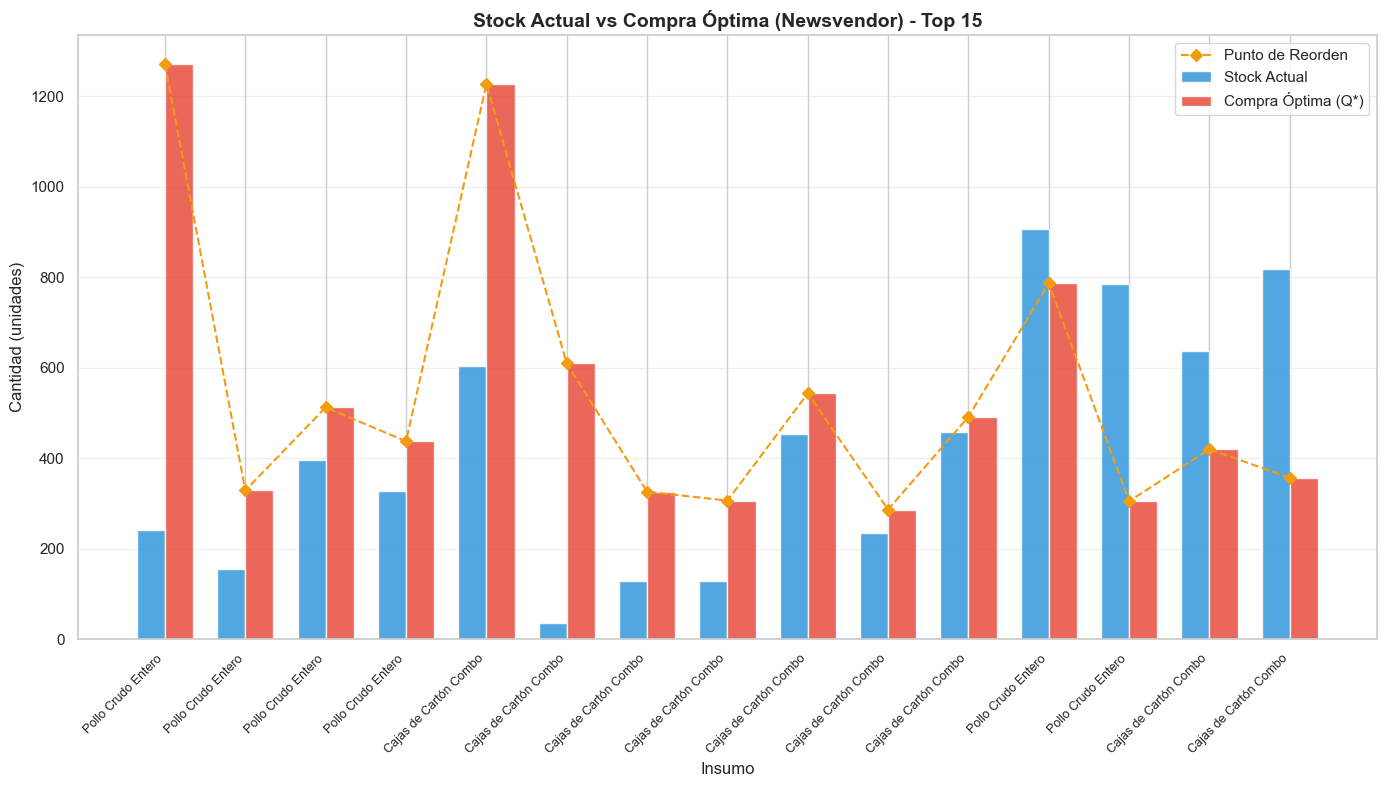

In [21]:
# Visualización: Compra óptima vs Stock actual (Top 15 por inversión)
top_n = 15
top_insumos = df_resultado.nlargest(top_n, 'COSTO_COMPRA_ESTIMADO')

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(top_insumos))
width = 0.35

bars1 = ax.bar(x - width/2, top_insumos['FEATURE_STOCK_ACTUAL'], width,
               label='Stock Actual', color='#3498db', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, top_insumos['COMPRA_OPTIMA'], width,
               label='Compra Óptima (Q*)', color='#e74c3c', alpha=0.85, edgecolor='white')

# Safety stock como línea
ax.plot(x, top_insumos['REORDER_POINT'], 'D--', color='#f39c12',
        markersize=6, linewidth=1.5, label='Punto de Reorden')

ax.set_xlabel('Insumo', fontsize=12)
ax.set_ylabel('Cantidad (unidades)', fontsize=12)
ax.set_title('Stock Actual vs Compra Óptima (Newsvendor) - Top 15', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(top_insumos['NOMBRE_INSUMO'], rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

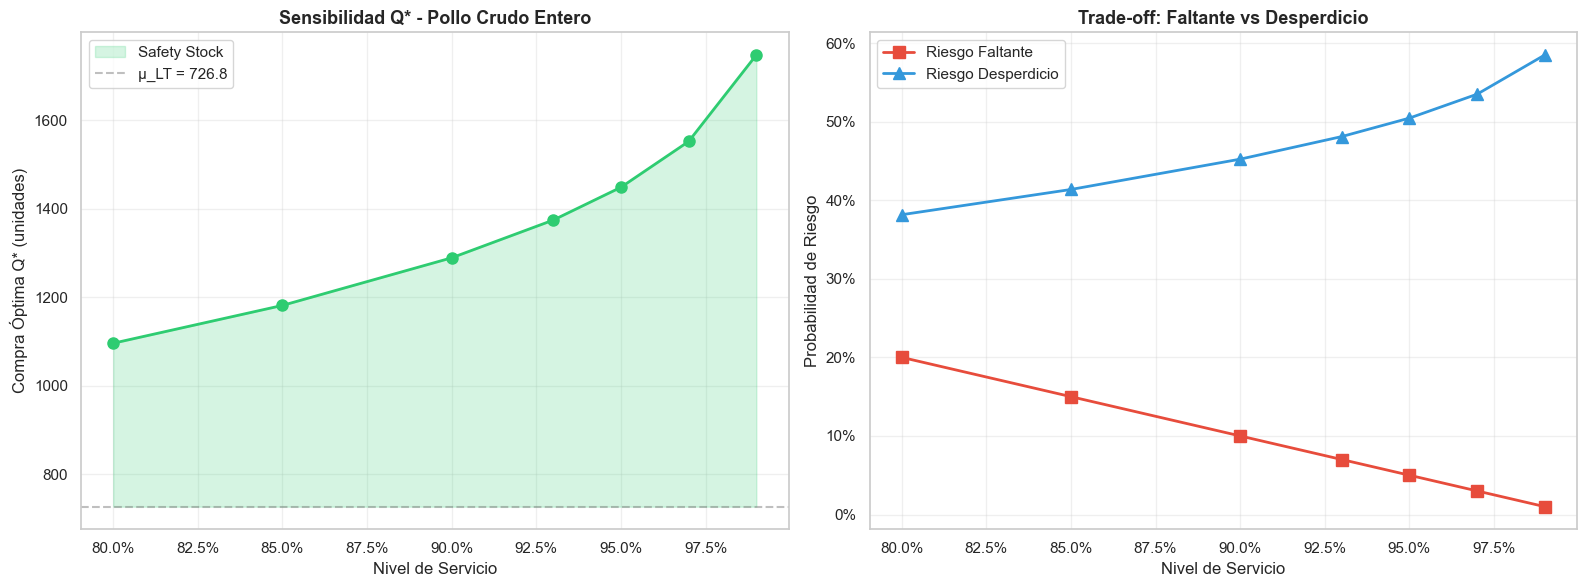

In [22]:
# Análisis de sensibilidad: ¿Cómo cambia Q* con diferentes niveles de servicio?
niveles_servicio = [0.80, 0.85, 0.90, 0.93, 0.95, 0.97, 0.99]

# Tomamos un insumo ejemplo (el de mayor demanda)
insumo_ejemplo = df_resultado.nlargest(1, 'FEATURE_DEMANDA_PROMEDIO_DIARIA').iloc[0]
mu_ej = insumo_ejemplo['FEATURE_DEMANDA_ESPERADA_LT']
sigma_ej = insumo_ejemplo['FEATURE_DESVIACION_DEMANDA_LT']
nombre_ej = insumo_ejemplo['NOMBRE_INSUMO']

q_optimos = []
riesgos_faltante = []
riesgos_desperdicio = []

for sl in niveles_servicio:
    z = stats.norm.ppf(sl)
    q = mu_ej + z * sigma_ej
    q_optimos.append(q)
    riesgos_faltante.append(1 - sl)
    if sigma_ej > 0 and q > 0:
        z_val = (q - mu_ej) / sigma_ej
        exceso = sigma_ej * (z_val * stats.norm.cdf(z_val) + stats.norm.pdf(z_val))
        riesgos_desperdicio.append(exceso / q)
    else:
        riesgos_desperdicio.append(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Q* vs Nivel de Servicio
ax1.plot(niveles_servicio, q_optimos, 'o-', color='#2ecc71', linewidth=2, markersize=8)
ax1.fill_between(niveles_servicio, mu_ej, q_optimos, alpha=0.2, color='#2ecc71', label='Safety Stock')
ax1.axhline(y=mu_ej, color='grey', linestyle='--', alpha=0.5, label=f'μ_LT = {mu_ej:.1f}')
ax1.set_xlabel('Nivel de Servicio', fontsize=12)
ax1.set_ylabel('Compra Óptima Q* (unidades)', fontsize=12)
ax1.set_title(f'Sensibilidad Q* - {nombre_ej}', fontweight='bold', fontsize=13)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico 2: Trade-off Faltante vs Desperdicio
ax2.plot(niveles_servicio, riesgos_faltante, 's-', color='#e74c3c', linewidth=2, markersize=8, label='Riesgo Faltante')
ax2.plot(niveles_servicio, riesgos_desperdicio, '^-', color='#3498db', linewidth=2, markersize=8, label='Riesgo Desperdicio')
ax2.set_xlabel('Nivel de Servicio', fontsize=12)
ax2.set_ylabel('Probabilidad de Riesgo', fontsize=12)
ax2.set_title('Trade-off: Faltante vs Desperdicio', fontweight='bold', fontsize=13)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

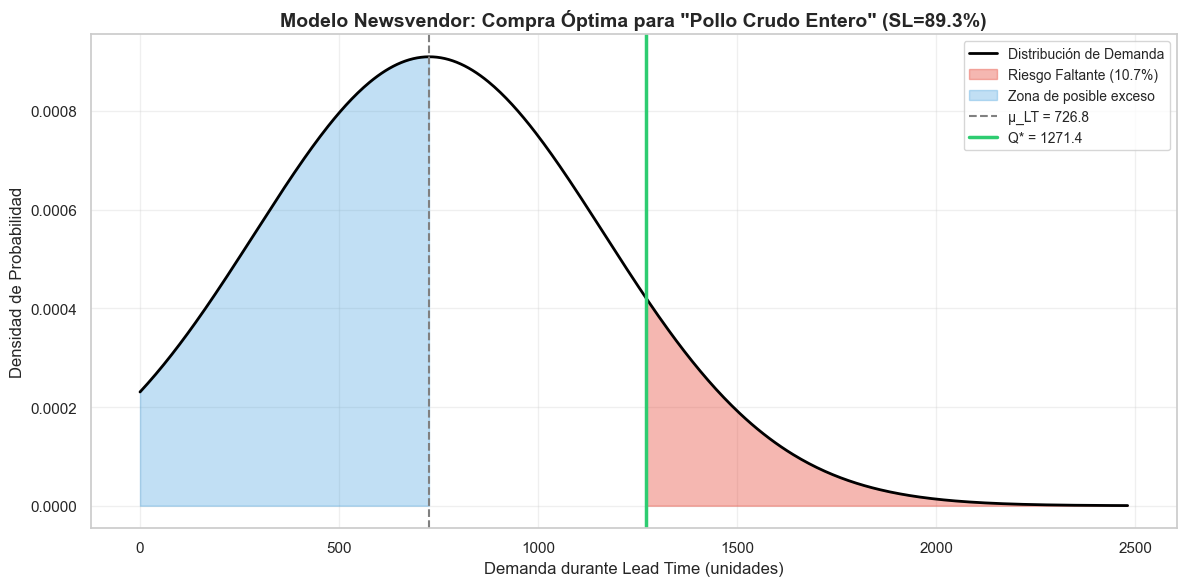


📋 Resultado para "Pollo Crudo Entero":
   Compra óptima Q*:        1271.43 Kg
   Safety Stock:            544.66 Kg
   Riesgo de faltante:      10.7%
   Lead time:               3 días


In [23]:
# Distribución de probabilidad para el insumo ejemplo
fig, ax = plt.subplots(figsize=(12, 6))

x_range = np.linspace(max(0, mu_ej - 4*sigma_ej), mu_ej + 4*sigma_ej, 500)
y_pdf = stats.norm.pdf(x_range, mu_ej, sigma_ej)

q_star = mu_ej + z_score * sigma_ej

# Curva de densidad
ax.plot(x_range, y_pdf, 'k-', linewidth=2, label='Distribución de Demanda')

# Área de faltante (demanda > Q*)
x_faltante = x_range[x_range >= q_star]
ax.fill_between(x_faltante, stats.norm.pdf(x_faltante, mu_ej, sigma_ej),
                alpha=0.4, color='#e74c3c', label=f'Riesgo Faltante ({1-SL:.1%})')

# Área de desperdicio (demanda < Q* - cierto margen)
x_desperdicio = x_range[x_range <= mu_ej]
ax.fill_between(x_desperdicio, stats.norm.pdf(x_desperdicio, mu_ej, sigma_ej),
                alpha=0.3, color='#3498db', label='Zona de posible exceso')

# Líneas de referencia
ax.axvline(x=mu_ej, color='grey', linestyle='--', linewidth=1.5, label=f'μ_LT = {mu_ej:.1f}')
ax.axvline(x=q_star, color='#2ecc71', linestyle='-', linewidth=2.5, label=f'Q* = {q_star:.1f}')

ax.set_xlabel('Demanda durante Lead Time (unidades)', fontsize=12)
ax.set_ylabel('Densidad de Probabilidad', fontsize=12)
ax.set_title(f'Modelo Newsvendor: Compra Óptima para "{nombre_ej}" (SL={SL:.1%})',
             fontweight='bold', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📋 Resultado para "{nombre_ej}":')
print(f'   Compra óptima Q*:        {q_star:.2f} {insumo_ejemplo["UNIDAD_MEDIDA"]}')
print(f'   Safety Stock:            {z_score * sigma_ej:.2f} {insumo_ejemplo["UNIDAD_MEDIDA"]}')
print(f'   Riesgo de faltante:      {1-SL:.1%}')
print(f'   Lead time:               {insumo_ejemplo["FEATURE_LEAD_TIME_DIAS"]:.0f} días')

## 5. 📊 Clasificación de Insumos por Prioridad de Compra

In [24]:
# Clasificar insumos por urgencia de compra
def clasificar_urgencia(row):
    """Clasifica la urgencia de compra del insumo."""
    cobertura = row['FEATURE_DIAS_COBERTURA_STOCK']
    lt = row['FEATURE_LEAD_TIME_DIAS']
    bajo_stock = row['FEATURE_INDICADOR_BAJO_STOCK']
    criticidad = row['FEATURE_NUM_PRODUCTOS_DEPENDIENTES']
    
    if bajo_stock == 1 and cobertura < lt:
        return '🔴 CRÍTICO'
    elif cobertura < lt * 1.5:
        return '🟠 URGENTE'
    elif cobertura < lt * 3:
        return '🟡 PLANIFICAR'
    else:
        return '🟢 OK'

df_resultado['URGENCIA'] = df_resultado.apply(clasificar_urgencia, axis=1)

# Resumen por urgencia
urgencia_resumen = df_resultado.groupby('URGENCIA').agg(
    cantidad_insumos=('ID_INSUMO_NK', 'count'),
    inversion_total=('COSTO_COMPRA_ESTIMADO', 'sum'),
    compra_promedio=('CANTIDAD_A_COMPRAR', 'mean')
).round(2)

print('📊 Resumen por Nivel de Urgencia:')
urgencia_resumen

📊 Resumen por Nivel de Urgencia:


,cantidad_insumos,inversion_total,compra_promedio
URGENCIA,,,
🔴 CRÍTICO,1,689.13,574.27
🟠 URGENTE,10,23531.60,259.96
🟡 PLANIFICAR,12,0.00,0.00
🟢 OK,1,0.00,0.00


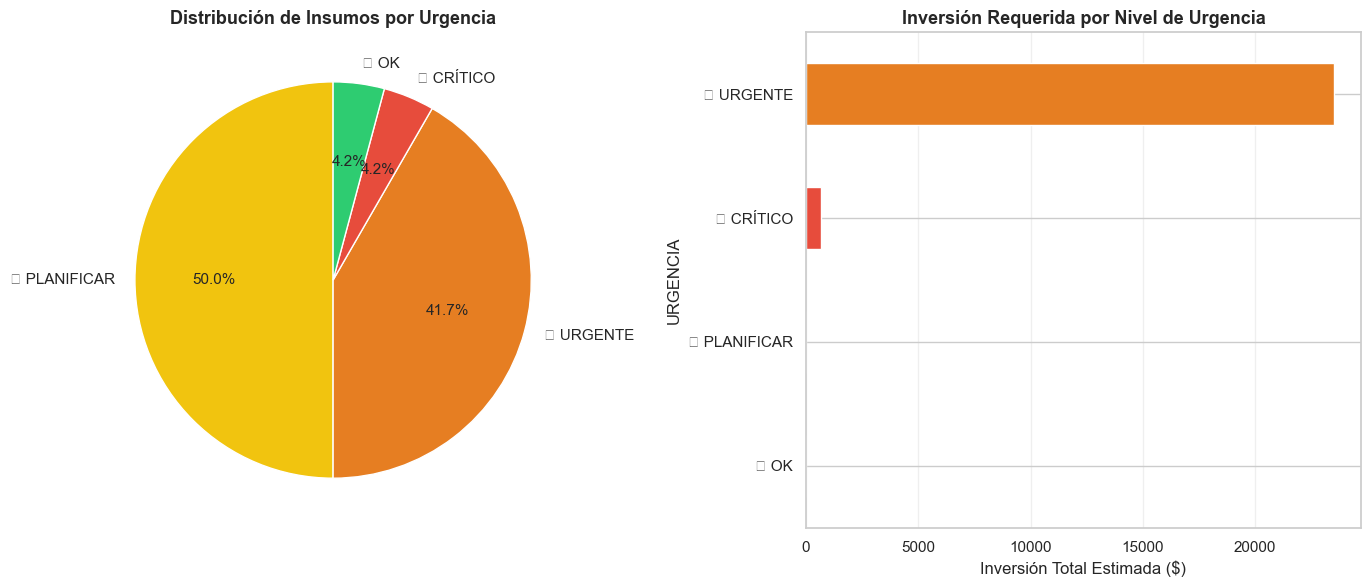

In [25]:
# Visualización de urgencia
colores_urgencia = {
    '🔴 CRÍTICO': '#e74c3c',
    '🟠 URGENTE': '#e67e22',
    '🟡 PLANIFICAR': '#f1c40f',
    '🟢 OK': '#2ecc71'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart: Distribución de urgencia
urgencia_counts = df_resultado['URGENCIA'].value_counts()
colors = [colores_urgencia.get(u, 'grey') for u in urgencia_counts.index]
ax1.pie(urgencia_counts, labels=urgencia_counts.index, colors=colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax1.set_title('Distribución de Insumos por Urgencia', fontweight='bold', fontsize=13)

# Bar chart: Inversión por urgencia
inv_por_urgencia = df_resultado.groupby('URGENCIA')['COSTO_COMPRA_ESTIMADO'].sum().sort_values(ascending=True)
bar_colors = [colores_urgencia.get(u, 'grey') for u in inv_por_urgencia.index]
inv_por_urgencia.plot(kind='barh', ax=ax2, color=bar_colors, edgecolor='white')
ax2.set_xlabel('Inversión Total Estimada ($)', fontsize=12)
ax2.set_title('Inversión Requerida por Nivel de Urgencia', fontweight='bold', fontsize=13)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 💾 Registro en MLflow y Exportación

In [26]:
# Registrar resultados en MLflow
mlflow.set_experiment('HGC_Inventory_Optimization')

with mlflow.start_run(run_name='Newsvendor_Optimization'):
    # Parámetros del modelo
    mlflow.log_param('modelo', 'Newsvendor')
    mlflow.log_param('nivel_servicio', round(SL, 4))
    mlflow.log_param('z_score', round(z_score, 4))
    mlflow.log_param('costo_faltante_factor', COSTO_FALTANTE_FACTOR)
    mlflow.log_param('costo_desperdicio_factor', COSTO_DESPERDICIO_FACTOR)
    mlflow.log_param('total_insumos_analizados', len(df_resultado))
    
    # Métricas globales
    mlflow.log_metric('compra_optima_promedio', df_resultado['COMPRA_OPTIMA'].mean())
    mlflow.log_metric('riesgo_faltante_promedio', df_resultado['RIESGO_FALTANTE'].mean())
    mlflow.log_metric('riesgo_desperdicio_promedio', df_resultado['RIESGO_DESPERDICIO'].mean())
    mlflow.log_metric('inversion_total_estimada', df_resultado['COSTO_COMPRA_ESTIMADO'].sum())
    mlflow.log_metric('insumos_criticos', len(df_resultado[df_resultado['URGENCIA'] == '🔴 CRÍTICO']))
    mlflow.log_metric('insumos_urgentes', len(df_resultado[df_resultado['URGENCIA'] == '🟠 URGENTE']))
    
    # Guardar CSV de resultados como artefacto
    resultado_path = 'inventory_optimization_results.csv'
    df_resultado[cols_resultado + ['URGENCIA', 'SAFETY_STOCK', 'REORDER_POINT']].to_csv(resultado_path, index=False)
    mlflow.log_artifact(resultado_path)
    
    print('✅ Resultados registrados en MLflow')
    print(f'   Experimento: HGC_Inventory_Optimization')
    print(f'   Run: Newsvendor_Optimization')

2026/04/16 02:40:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/16 02:40:52 INFO mlflow.store.db.utils: Updating database tables
2026/04/16 02:40:54 INFO mlflow.tracking.fluent: Experiment with name 'HGC_Inventory_Optimization' does not exist. Creating a new experiment.


✅ Resultados registrados en MLflow
   Experimento: HGC_Inventory_Optimization
   Run: Newsvendor_Optimization


## 7. 📋 Resumen Ejecutivo

### Impacto Esperado

| Métrica | Antes | Después |
|---------|-------|--------|
| Método de compra | Subjetivo / Histórico fijo | Optimizado bajo incertidumbre |
| Quiebres de stock | Frecuentes | Controlados al SL definido |
| Desperdicio | Sin control | Minimizado con trade-off óptimo |
| Decisión | "Compro lo mismo que siempre" | "Compro Q* con X% riesgo" |

### Próximos pasos
1. Validar con datos reales de desperdicio histórico
2. Ajustar costos Cu/Co con el equipo de operaciones
3. Automatizar la ejecución periódica (pipeline MLOps)
4. Integrar con sistema de órdenes de compra

In [27]:
# Cerrar conexión
conn.close()
print('✅ Conexión a Snowflake cerrada')
print()
print('=' * 50)
print('  OPTIMIZACIÓN DE INVENTARIO COMPLETADA')
print('=' * 50)
print(f'  Modelo:              Newsvendor')
print(f'  Nivel de servicio:   {SL:.1%}')
print(f'  Insumos analizados:  {len(df_resultado)}')
print(f'  Inversión estimada:  ${df_resultado["COSTO_COMPRA_ESTIMADO"].sum():,.2f}')
print('=' * 50)

✅ Conexión a Snowflake cerrada

  OPTIMIZACIÓN DE INVENTARIO COMPLETADA
  Modelo:              Newsvendor
  Nivel de servicio:   89.3%
  Insumos analizados:  24
  Inversión estimada:  $24,220.73
